In [1]:
import allel
import zarr
import numcodecs
import numpy as np
import sys
import pandas as pd
import matplotlib.pyplot as plt
from collections import *
from sklearn.cluster import KMeans
from matplotlib.legend_handler import HandlerLine2D

In [255]:
#vcf_path = "/Users/rainlam/QUL/QUL.LG1.vcf.gz"
vcf_path = "/Users/rainlam/Project/3.SV/Aripo.LG12.vcf.gz"
zarr_path = "/Users/rainlam/QUL/QUL_zarr"

In [256]:
# transform vcf to zarr
# allel.vcf_to_zarr(vcf_path, zarr_path, group='22', fields='*', log=sys.stdout, overwrite=True)

In [342]:
# extract genotype data from VCF file 
#callset = allel.read_vcf(vcf_path, region='LR880645.1:18500000-20500000')
chromosome = "LR880656.1"
start = "16000000"
end = "26000000"
callset = allel.read_vcf(vcf_path, region='{}:{}-{}'.format(chromosome, start, end), 
                         samples=['ArL-F10', 'ArL-F15', 'ArL-F16', 'ArL-F18',
       'ArL-F19', 'ArL-F20', 'ArL-F22', 'ArL-F5', 'ArL-F8', 'ArL-F9',
       'ArL-M11', 'ArL-M12', 'ARL-M15', 'ArL-M16', 'ARL-M17', 'ArL-M19',
       'ArL-M1', 'ArL-M24', 'ARL-M25', 'ArL-M6'])
#callset = allel.read_vcf(vcf_path)
# genotype 
g = allel.GenotypeArray(callset['calldata/GT'])
#allel.GenotypeAlleleCounts(vcf_path)

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/allel/io/vcf_read.py:1047: UserWarning: error occurred attempting tabix (Could not load .tbi/.csi index of /Users/rainlam/Project/3.SV/Aripo.LG12.vcf.gz); falling back to scanning to region
  warnings.warn('error occurred attempting tabix (%s); falling back to '
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/allel/io/vcf_read.py:1732: UserWarning: invalid INFO header: '##INFO=<ID=VDB,Number=1,Type=Float,Description="Variant Distance Bias for filtering splice-site artefacts in RNA-seq data (bigger is better)",Version="3">\n'
  warnings.warn('invalid INFO header: %r' % header)


In [343]:
ac = g.count_alleles()[:]
# SNP filtering
flt = (ac.max_allele() == 1) & (ac[:, :2].min(axis=1) > 1)
gf = g.compress(flt, axis=0)
gn = gf.to_n_alt()
gn

array([[2, 2, 1, ..., 1, 2, 2],
       [2, 2, 1, ..., 1, 2, 2],
       [2, 2, 1, ..., 1, 2, 2],
       ...,
       [0, 0, 0, ..., 1, 1, 0],
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 1, 1, 0]], dtype=int8)

In [344]:
gf

<GenotypeArray shape=(84561, 20, 2) dtype=int8>
1/1 1/1 0/1 1/1 1/1 ... 1/1 1/1 0/1 1/1 1/1
1/1 1/1 0/1 1/1 1/1 ... 1/1 1/1 0/1 1/1 1/1
1/1 1/1 0/1 1/1 1/1 ... 1/1 1/1 0/1 1/1 1/1
...
0/0 0/0 0/0 0/0 0/0 ... 0/0 0/0 0/1 0/1 0/0
0/0 0/0 0/0 0/0 0/0 ... 0/0 0/0 0/1 0/0 0/0
0/0 0/0 0/0 0/0 0/0 ... 0/0 0/0 0/1 0/1 0/0

In [345]:
callset['samples']

array(['ArL-F10', 'ArL-F15', 'ArL-F16', 'ArL-F18', 'ArL-F19', 'ArL-F20',
       'ArL-F22', 'ArL-F5', 'ArL-F8', 'ArL-F9', 'ArL-M11', 'ArL-M12',
       'ARL-M15', 'ArL-M16', 'ARL-M17', 'ArL-M19', 'ArL-M1', 'ArL-M24',
       'ARL-M25', 'ArL-M6'], dtype=object)

In [346]:
coords1, model1 = allel.pca(gn, n_components=10, scaler='patterson')

In [347]:
sample_list = []
for i in range(len(callset['samples'])):
    het_count = g[:,i].count_het()
    prop_het_sample = het_count*100 / 1500000
    sample_list.append([callset['samples'][i], coords1[i][0], coords1[i][1], prop_het_sample])
df = pd.DataFrame(sample_list, columns=["samples",
                                        "PC1", "PC2", "hetero"])

In [353]:
X = df[['PC1']]
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3)

In [354]:
df

,samples,PC1,PC2,hetero,cluster,sex,pop
0,ArL-F10,-79.737465,73.825920,1.284400,0,F,QUL
1,ArL-F15,-51.967598,103.159668,2.054000,0,F,QUL
2,ArL-F16,522.403503,-124.910156,3.474200,1,F,QUL
3,ArL-F18,-80.271301,114.054329,1.362533,0,F,QUL
4,ArL-F19,-109.727356,26.389202,1.118000,0,F,QUL
5,ArL-F20,-104.068138,52.181263,1.192467,0,F,QUL
6,ArL-F22,24.596235,221.587708,2.430733,0,F,QUL
7,ArL-F5,442.640259,159.780304,3.122533,1,F,QUL
8,ArL-F8,141.572723,104.454430,2.236133,0,F,QUL
9,ArL-F9,-102.126190,43.967972,1.379333,0,F,QUL


In [355]:
kmeans.fit(X)
df_cl = X.copy()
# add one more column
df_cl['cluster'] = kmeans.predict(X)
df_cl
df["cluster"] = kmeans.predict(X)
#df["sex"] = ["M"]*10 + ['F'] *10
#df["sex"] = ["F"]*10 + ['M'] *10 + ["F"]*10 + ['M'] *10 
df["sex"] = ["F"]*10 + ['M'] *10 
#df['pop'] = ['QUH'] * 20 + ['QUL'] * 20
df['pop'] =  ['QUL'] * 20

In [356]:
df

,samples,PC1,PC2,hetero,cluster,sex,pop
0,ArL-F10,-79.737465,73.825920,1.284400,0,F,QUL
1,ArL-F15,-51.967598,103.159668,2.054000,0,F,QUL
2,ArL-F16,522.403503,-124.910156,3.474200,1,F,QUL
3,ArL-F18,-80.271301,114.054329,1.362533,0,F,QUL
4,ArL-F19,-109.727356,26.389202,1.118000,0,F,QUL
5,ArL-F20,-104.068138,52.181263,1.192467,0,F,QUL
6,ArL-F22,24.596235,221.587708,2.430733,2,F,QUL
7,ArL-F5,442.640259,159.780304,3.122533,1,F,QUL
8,ArL-F8,141.572723,104.454430,2.236133,2,F,QUL
9,ArL-F9,-102.126190,43.967972,1.379333,0,F,QUL


Text(0, 0.5, 'Heterzygosity')

<Figure size 3000x2000 with 0 Axes>

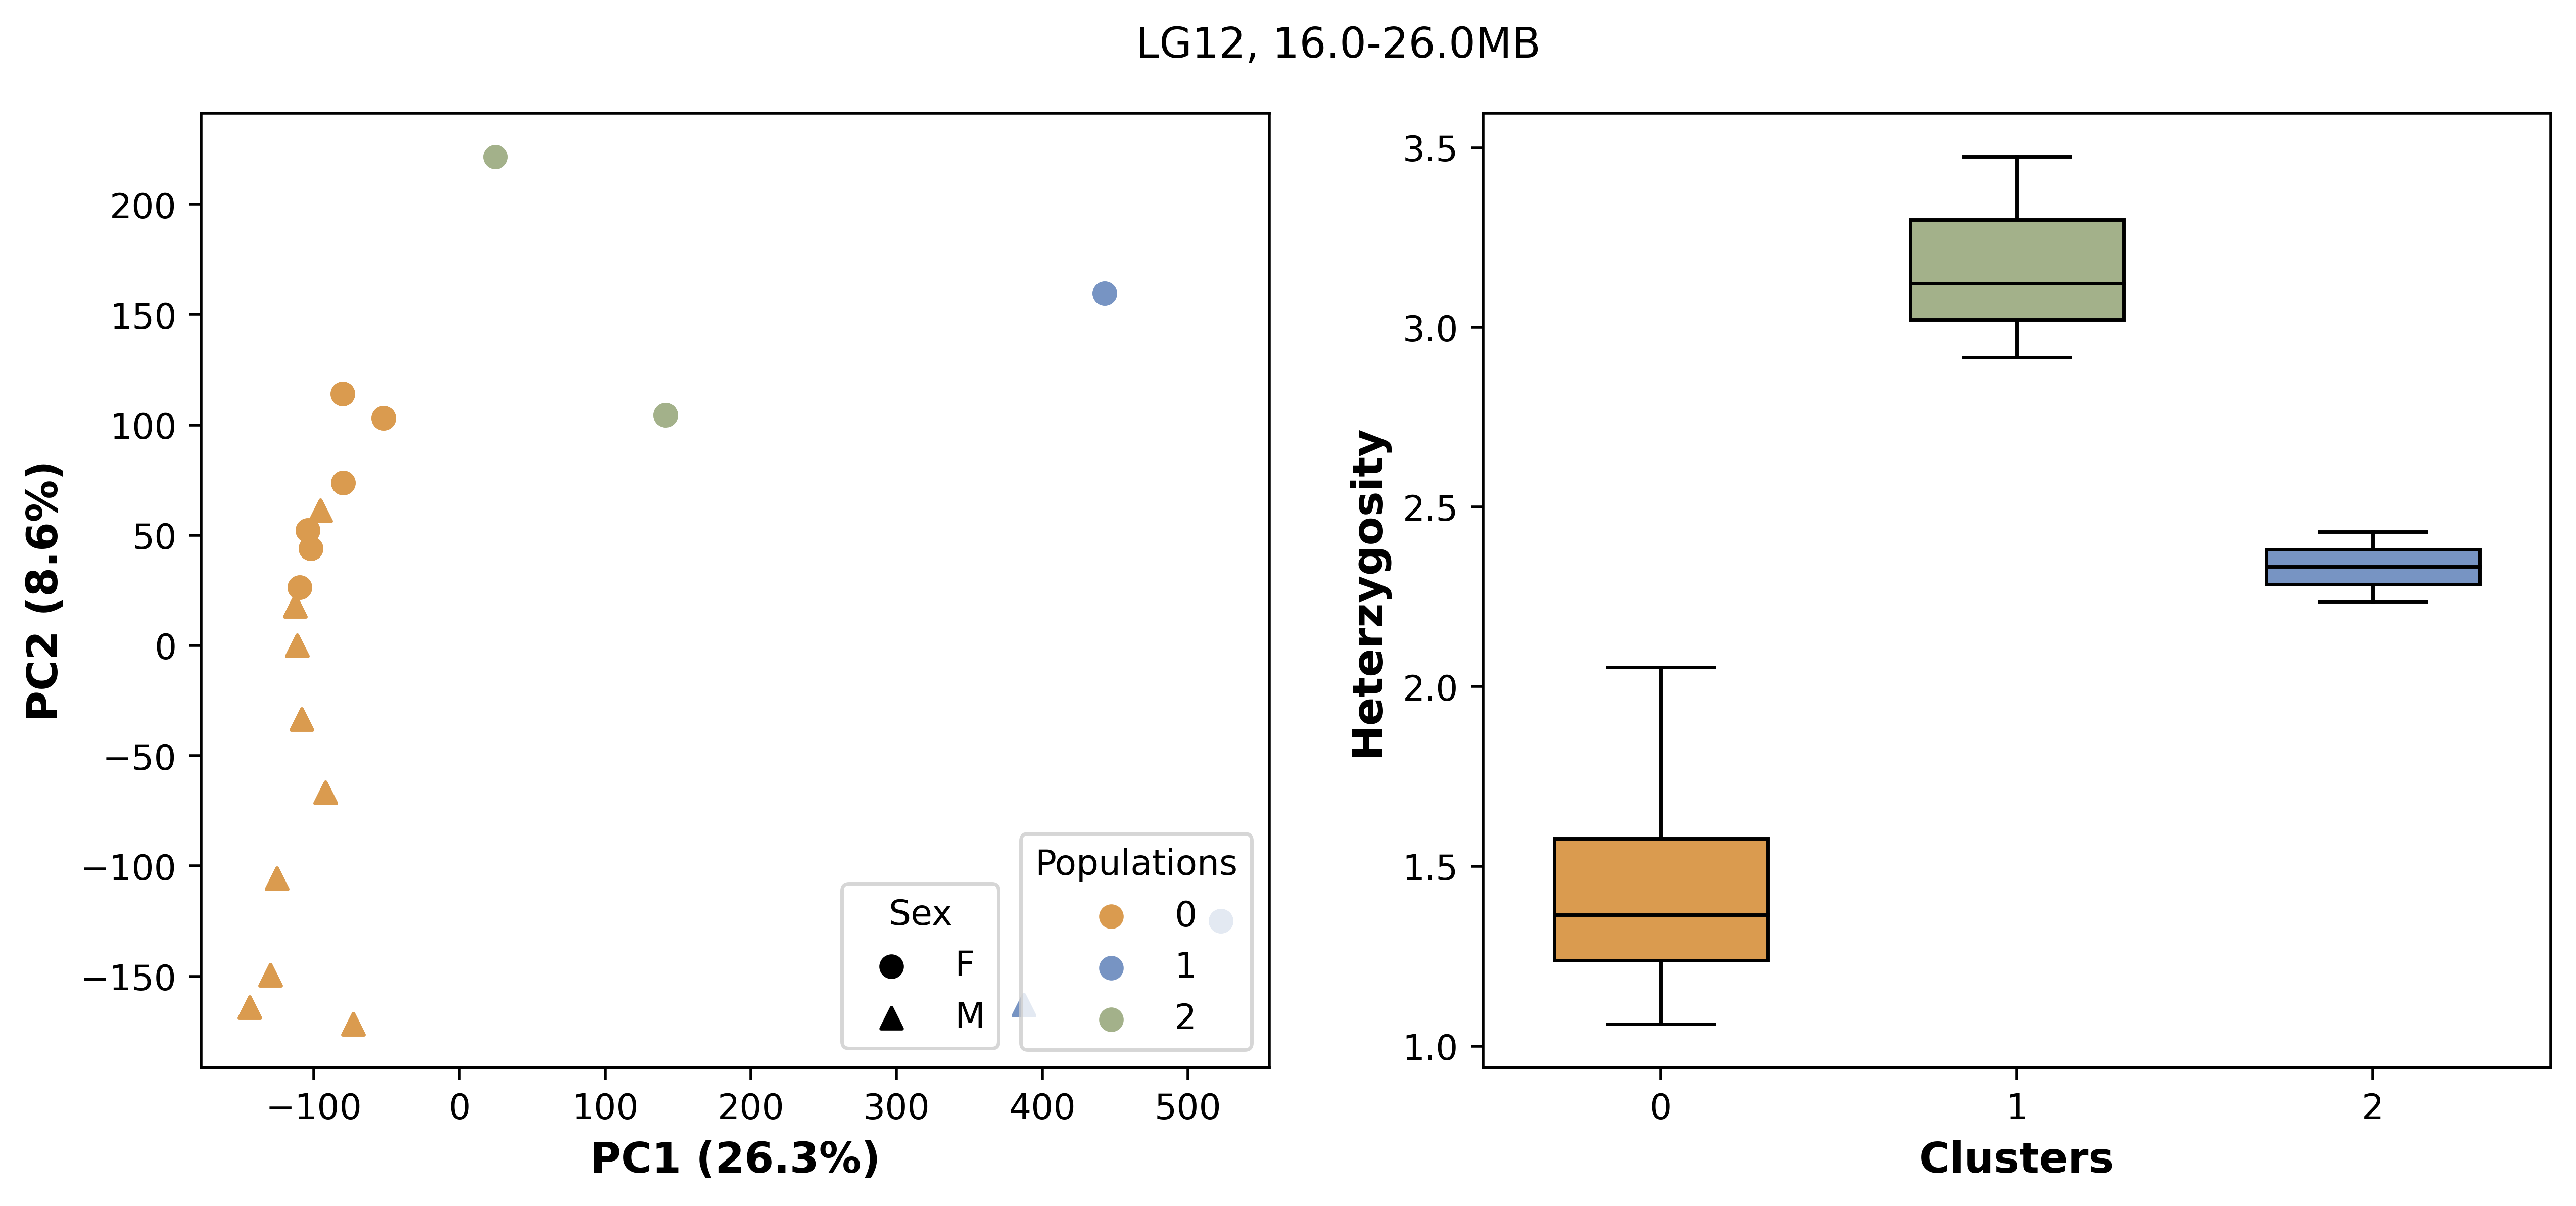

In [363]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
plt.figure(dpi = 500)
# plt.title("LG12, 2-3.5MB")
fig, axs = plt.subplots(1, 2, figsize=(12, 5), dpi = 500)
fig.suptitle("LG12, {}-{}MB".format(str(int(start)/1000000), str(int(end)/1000000)), y=0.95)

# Read data into a pandas dataframe

#cluster_colors = {'0':'#DA9B4F', '1':'#7794C3', '2':'#A3B18A'}
sex_markers = {"F":"o", "M":"^"}
#pop_colors = {"QUH": "#DA9B4F", "QUL": '#7794C3'}
#pop_colors = {'QUH':'#DA9B4F', 'QUL':'#A3B18A'}
pop_colors = {'0':'#DA9B4F', '1':'#7794C3', '2':'#A3B18A'}
# Plot the clusters
for pop in pop_colors.keys():
    for s in sex.keys():
        subset = df[(df['cluster'] == int(pop)) & (df['sex'] == s)]
        axs[0].scatter(subset['PC1'], subset['PC2'], color=pop_colors[pop],
                       marker=sex_markers[s], label=f'{pop}')
        axs[0].scatter(subset['PC1'], subset['PC2'], color=pop_colors[pop],
                       marker=sex_markers[s], label=f'{s}')
        
##### previous 
# for pop in cluster_colors.keys():
#     for s in sex.keys():
#         subset = df[(df['cluster'] == int(pop)) & (df['sex'] == s)]
#         axs[0].scatter(subset['PC1'], subset['PC2'], color=cluster_colors[pop],
#                        marker=sex_markers[s], label=f'{pop}')
#         axs[0].scatter(subset['PC1'], subset['PC2'], color=cluster_colors[pop],
#                        marker=sex_markers[s], label=f'{s}')
        
# # Add legend for population
handles, labels = [], []
for pop in pop_colors.keys():
    handles.append(plt.scatter([], [], color=pop_colors[pop], marker='o'))
    labels.append(pop)
first_legend = axs[0].legend(handles, labels, title='Populations', loc="lower right")
axs[0].add_artist(first_legend)

# # Add legend for sex
handles, labels = [], []
for s in sex.keys():
    handles.append(plt.scatter([], [], color='black', marker=sex[s]))
    labels.append(s)
axs[0].legend(handles, labels, title='Sex', loc=[0.60, 0.02])

# lables
pc1=0
pc2=1

axs[0].set_xlabel(('PC%s (%.1f%%)' % (pc1+1, model1.explained_variance_ratio_[pc1]*100)), fontsize=12, fontweight="bold")
axs[0].set_ylabel(('PC%s (%.1f%%)' % (pc2+1, model1.explained_variance_ratio_[pc2]*100)), fontsize=12, fontweight="bold")



# Fig 2.1 Define the colors

# plot violin plot for cluster 0
bplot1 = axs[1].boxplot(df.loc[df["cluster"] == 0, "hetero"], positions=[0], widths=0.6, 
                        patch_artist=True, medianprops=dict(color="black"))

# plot violin plot for cluster 0
bplot2 = axs[1].boxplot(df.loc[df["cluster"] == 1, "hetero"], positions=[1], widths=0.6,
                        patch_artist=True,  medianprops=dict(color="black"))

# plot violin plot for cluster 1
bplot3 = axs[1].boxplot(df.loc[df["cluster"] == 2, "hetero"], positions=[2], widths=0.6,
                        patch_artist=True,  medianprops=dict(color="black"))
              
colors = ['#DA9B4F', '#A3B18A', '#7794C3']
# Set the facecolor for each box
for bplot, color in zip([bplot1, bplot2, bplot3], colors):
    for patch in bplot['boxes']:
        patch.set_color(color)
        patch.set_facecolor(color)
        patch.set_edgecolor("black")
axs[1].set_xticklabels(["0", "1", "2"])

axs[1].set_xlabel("Clusters", fontsize=12, fontweight="bold")
axs[1].set_ylabel("Heterzygosity", fontsize=12, fontweight="bold")



In [165]:
plt.

['#DA9B4F', '#7794C3', '#A3B18A']

## 2. LD decay

In [4]:
df_Aripo = pd.read_csv("/Users/rainlam/Aripo_LDdecay.stat", header='infer', delimiter="\t")
df_Quare = pd.read_csv("/Users/rainlam/Quare_LDdecay.stat", header='infer', delimiter="\t")
df_Yarra = pd.read_csv("/Users/rainlam/Yarra_LDdecay.stat", header='infer', delimiter="\t")

In [7]:
df_Aripo.columns

Index(['#Dist', 'Mean_r^2', 'Mean_D'', 'Sum_r^2', 'Sum_D'', 'NumberPairs'], dtype='object')

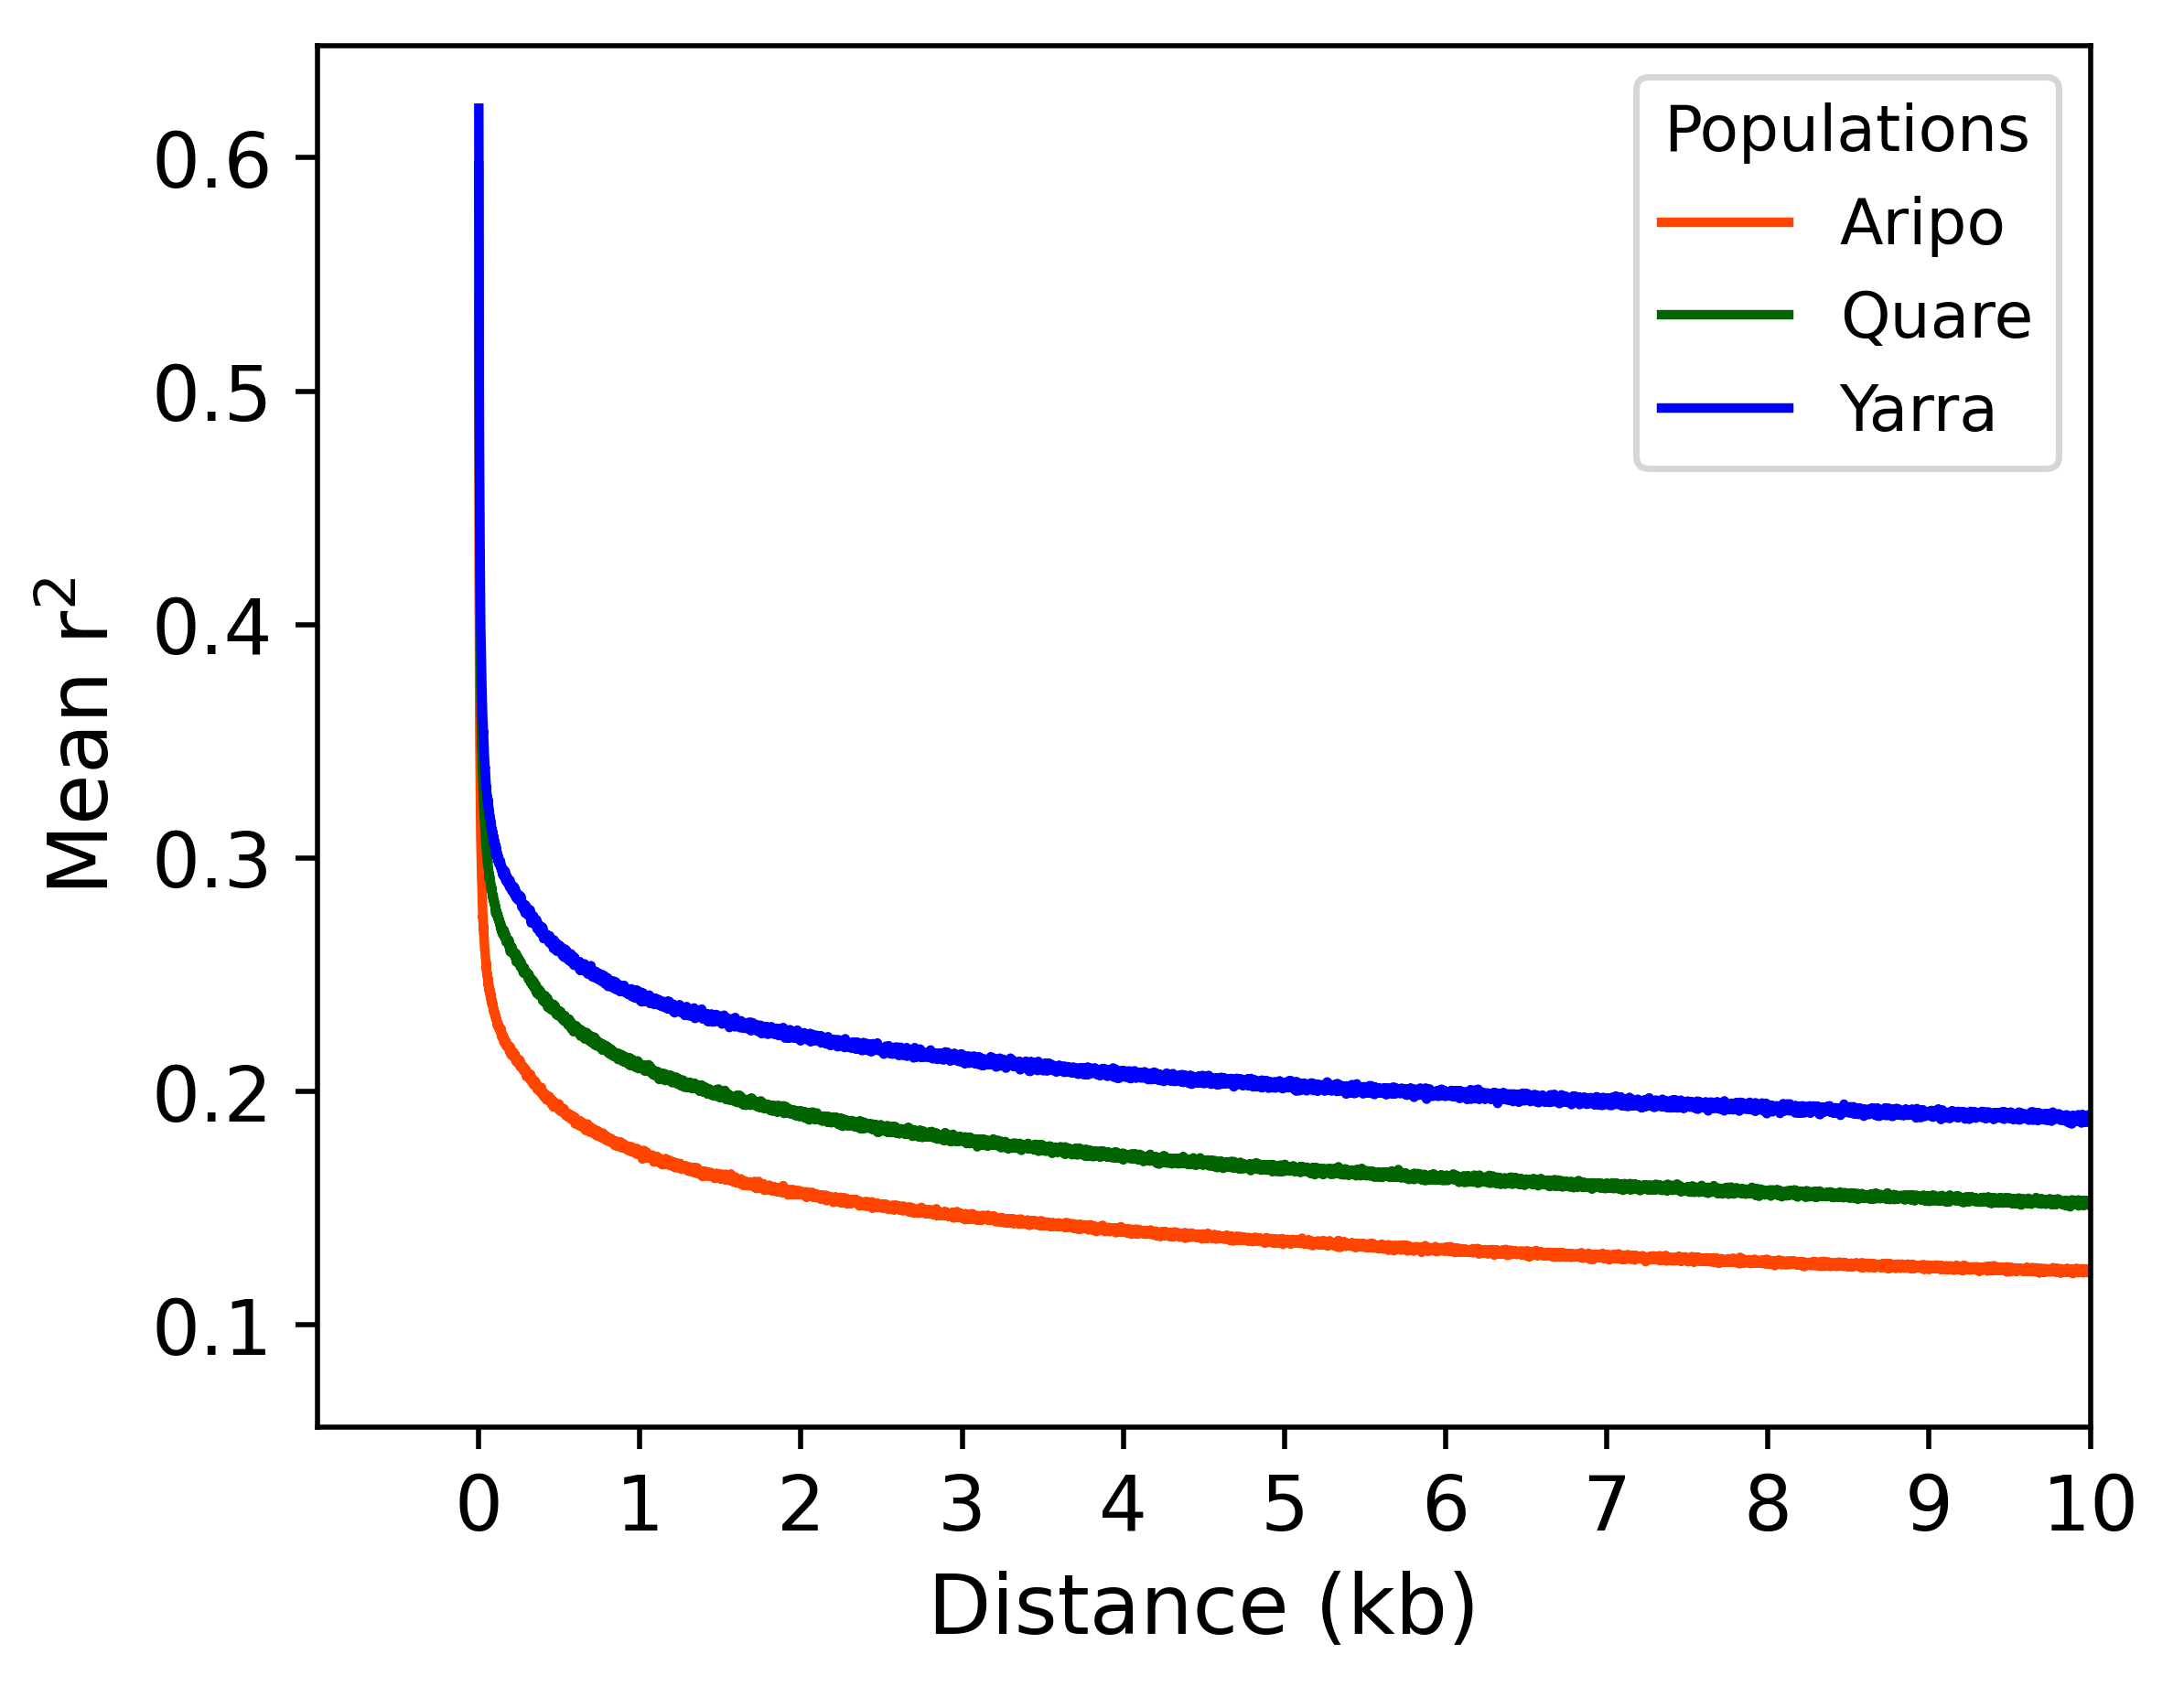

In [16]:
plt.figure(figsize=(5,4), dpi = 500)
plt.plot(df_Aripo['#Dist'], df_Aripo['Mean_r^2'], label='Aripo', color="orangered")
plt.plot(df_Quare['#Dist'], df_Quare['Mean_r^2'], label='Quare', color="darkgreen")
plt.plot(df_Yarra['#Dist'], df_Yarra['Mean_r^2'], label='Yarra', color="blue")
plt.ylabel("Mean r$^2$", fontsize=13)
plt.xlabel("Distance (kb)", fontsize=13)
plt.xticks(list(range(0,11000, 1000)),list(range(0,11,1)), fontsize=12)
plt.xlim(-1000,10000)
plt.yticks(fontsize=12)
plt.legend(title="Populations")
plt.savefig("LDdecay_3pop.pdf", format="pdf")